In [1]:
import matplotlib.pyplot as plt
import pandas as pd

READING CSV FILE (Netflix Data)

In [3]:
df = pd.read_csv(r"E:\M L\PYTHON\MATPLOTLIB\netflix_titles.csv")
df = df.dropna(subset = ["type", "release_year", "rating", "country", "duration"])
type_counts = df["type"].value_counts()

In [4]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
15,s16,TV Show,Dear White People,NaN,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...
17,s18,TV Show,Falsa identidad,NaN,"Luis Ernesto Franco, Camila Sodi, Sergio Goyri...",Mexico,"September 22, 2021",2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ...",Strangers Diego and Isabel flee their home in ...
21,s22,TV Show,Resurrection: Ertugrul,NaN,"Engin Altan Düzyatan, Serdar Gökhan, Hülya Dar...",Turkey,"September 22, 2021",2018,TV-14,5 Seasons,"International TV Shows, TV Action & Adventure,...",When a good deed unwittingly endangers his cla...


Number of Movies VS TV Shows on Netflix

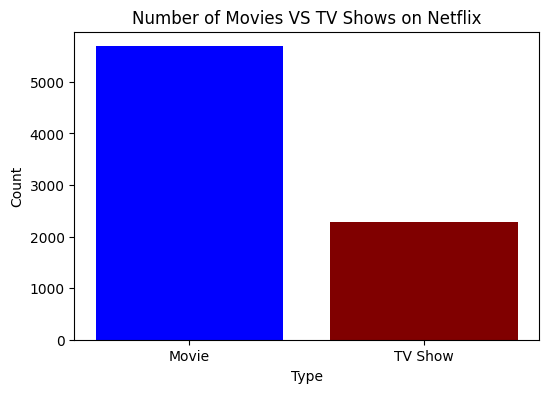

In [5]:
plt.figure(figsize = (6,4)) 
plt.bar(type_counts.index, type_counts.values, color = ["blue", "maroon"])
plt.title("Number of Movies VS TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Rating

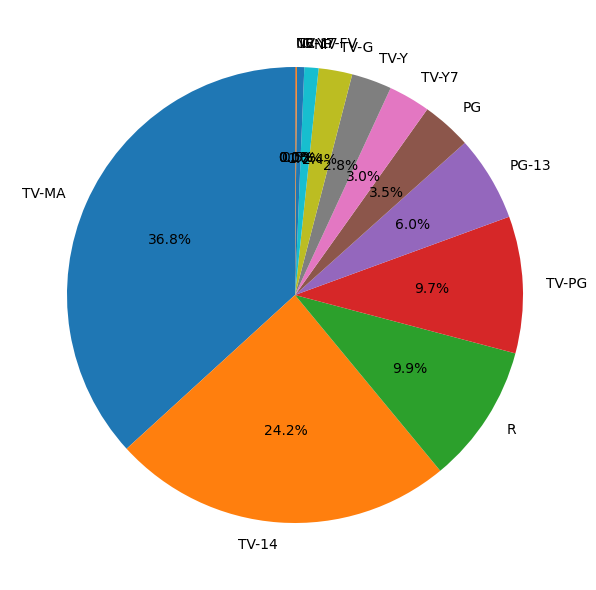

In [7]:
rating_counts = df["rating"].value_counts()
plt.figure(figsize = (8, 6))
plt.pie(rating_counts, labels = rating_counts.index, autopct="%1.1f%%", startangle = 90 ) # startangle = 90 ->first slice starts at TOP
plt.tight_layout()
plt.show()

Distribution Of Movies Duration

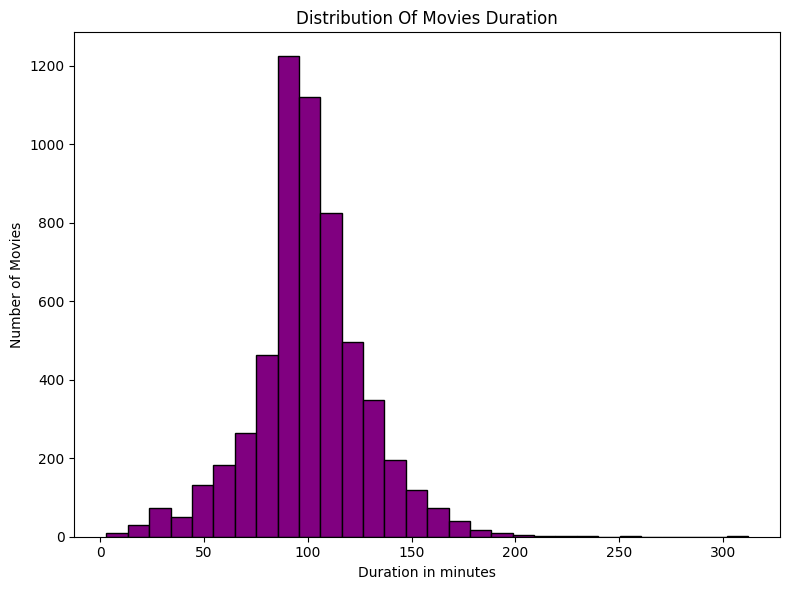

In [8]:
movie_df = df[df["type"] == "Movie"].copy()
movie_df["duration_int"] = movie_df["duration"].str.replace("min","").astype(int)
plt.figure(figsize = (8, 6))
plt.hist(movie_df["duration_int"], bins = 30, color = "purple", edgecolor = "black")
plt.title("Distribution Of Movies Duration")
plt.xlabel("Duration in minutes")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

Release year vs number of shows

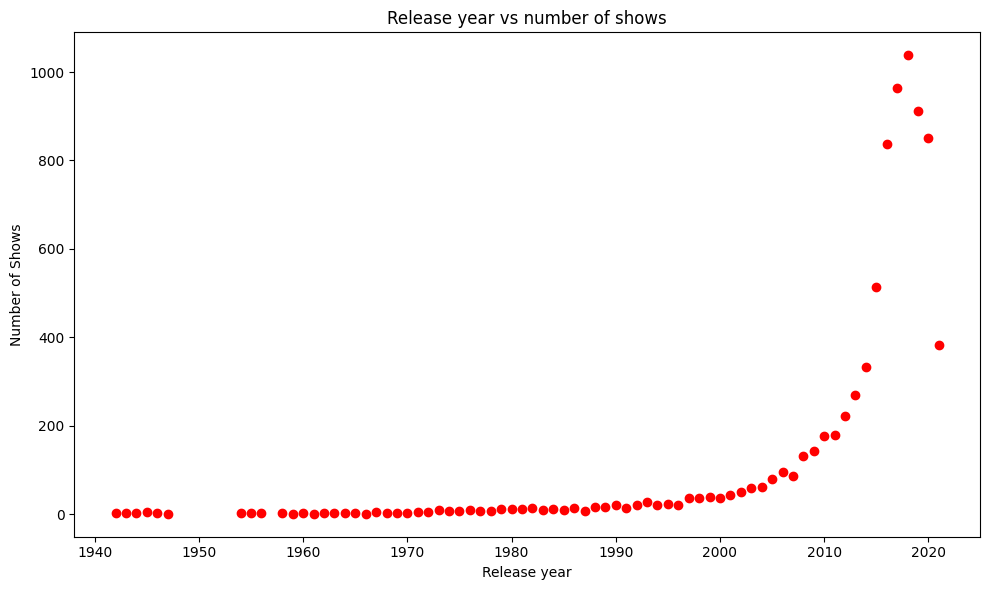

In [9]:
release_counts = df["release_year"].value_counts().sort_index()
plt.figure(figsize = (10, 6))
plt.scatter(release_counts.index, release_counts.values, color = "red")
plt.title("Release year vs number of shows")
plt.xlabel("Release year")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.show()


Top 10 countries by number of shows

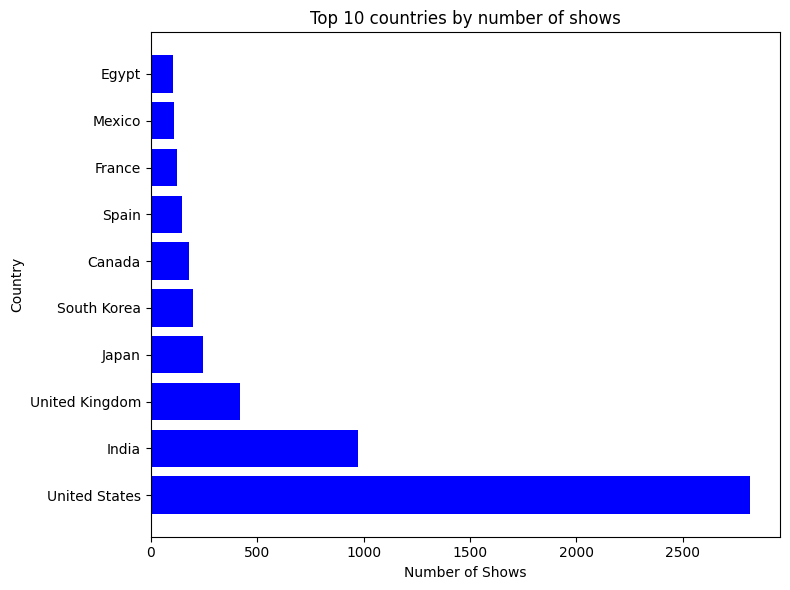

In [10]:
country_counts =df["country"].value_counts().head(10)
plt.figure(figsize = (8, 6))
plt.barh(country_counts.index, country_counts.values, color = "blue")
plt.title("Top 10 countries by number of shows")
plt.xlabel("Number of Shows")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Comparison of Movies and TV Shows Released Over Years

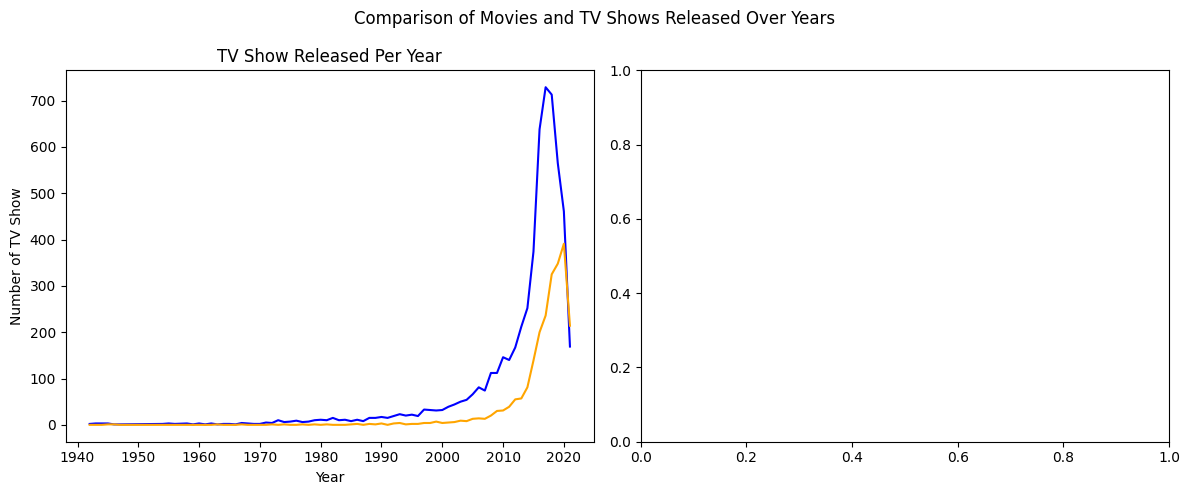

In [15]:
content_by_year = df.groupby(["release_year", "type"]).size().unstack().fillna(0)

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

ax[0].plot(content_by_year.index, content_by_year["Movie"], color = "blue")
ax[0].set_title("Movies Released Per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of Movies")

ax[0].plot(content_by_year.index, content_by_year["TV Show"], color = "orange")
ax[0].set_title("TV Show Released Per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of TV Show")

fig.suptitle("Comparison of Movies and TV Shows Released Over Years")
plt.tight_layout()

plt.show()